# **Loading the data**

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from skimage import exposure
import pickle
import random
import sys
import gc

In [2]:
K = 5
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-3
Class_Names = ["Glioma", "Meningioma", "Pituitary"]

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
base_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή"

In [5]:
sys.path.append('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή')
from PreProcessing_Script import dataset_preparation

In [6]:
cnn_root_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model"

def create_experiment_folders(experiment_name):
    experiment_dir = os.path.join(cnn_root_dir, experiment_name)
    results_dir = os.path.join(experiment_dir, "results")
    images_dir = os.path.join(results_dir, "images")
    models_dir = os.path.join(results_dir, "models")
    report_dir = os.path.join(results_dir, "report")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    return {
        "experiment_dir": experiment_dir,
        "results_dir": results_dir,
        "images_dir": images_dir,
        "models_dir": models_dir,
        "report_dir": report_dir
    }

In [7]:
x_train_val_raw = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/x_train_val_raw.pkl","rb"))
x_test_raw      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/x_test_raw.pkl","rb"))
y_train_val_int = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/y_train_val_int.pkl","rb"))
y_test_int      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/pickle_data/y_test_int.pkl","rb"))

In [8]:
input_shape = (x_train_val_raw.shape[1], x_train_val_raw.shape[2])

# Saving

In [9]:
def get_save_paths(model_or_experiment_name):
    if isinstance(model_or_experiment_name, str):
        experiment_name = model_or_experiment_name
    else:
        experiment_name = model_or_experiment_name.experiment_name

    folders = create_experiment_folders(experiment_name)

    paths = {
        "model": os.path.join(folders["models_dir"], f"{experiment_name}.keras"),
        "train_loss": os.path.join(folders["images_dir"], f"{experiment_name}_train_loss.png"),
        "train_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_train_accuracy.png"),
        "confusion_matrix": os.path.join(folders["images_dir"], f"{experiment_name}_confusion_matrix.png"),
        "roc_curve": os.path.join(folders["images_dir"], f"{experiment_name}_roc_curve.png"),
        "auc_report": os.path.join(folders["report_dir"], f"{experiment_name}_auc_report.txt"),
        "classification_report": os.path.join(folders["report_dir"], f"{experiment_name}_classification_report.txt"),
        "confusion_matrix_txt": os.path.join(folders["report_dir"], f"{experiment_name}_confusion_matrix.txt"),
        "kfold_metrics": os.path.join(folders["report_dir"], f"{experiment_name}_kfold_metrics.txt")
    }

    return paths

# **Plots**

In [10]:
def acc_and_loss(history, model_experiment_name, save_paths=None):
  hist = history.history

  epochs_acc = np.arange(1, len(hist["accuracy"])+1)
  epochs_loss = np.arange(1, len(hist["loss"])+1)

  fig_acc, ax_acc = plt.subplots(figsize=(10,5), dpi = 120)
  ax_acc.plot(
      epochs_acc,
      hist["accuracy"],
      label = "Training Accuracy",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_accuracy" in hist:
    ax_acc.plot(
        epochs_acc,
        hist["val_accuracy"],
        label = "Validation Accuracy",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_acc.set_title(f"{model_experiment_name} - Accuracy")
  ax_acc.set_xlabel("Epochs")
  ax_acc.set_ylabel("Accuracy")
  ax_acc.grid(True, alpha = 0.3)
  ax_acc.legend()
  fig_acc.tight_layout()

  if save_paths is not None and "train_accuracy" in save_paths:
    fig_acc.savefig(save_paths["train_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

  fig_loss, ax_loss = plt.subplots(figsize=(10,5), dpi = 120)
  ax_loss.plot(
      epochs_loss,
      hist["loss"],
      label = "Training Loss",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_loss" in hist:
    ax_loss.plot(
        epochs_loss,
        hist["val_loss"],
        label = "Validation Loss",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_loss.set_title(f"{model_experiment_name} - Loss")
  ax_loss.set_xlabel("Epochs")
  ax_loss.set_ylabel("Loss")
  ax_loss.grid(True, alpha = 0.3)
  ax_loss.legend()
  fig_loss.tight_layout()

  if save_paths is not None and "train_loss" in save_paths:
    fig_loss.savefig(save_paths["train_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  print('Loss:')
  print('  - loss [training dataset]: {:.3f}'.format(hist['loss'][-1]))
  if 'val_loss' in hist:
      print('  - loss [validation dataset]: {:.3f}'.format(hist['val_loss'][-1]))

  print('')
  print('Accuracy:')
  print('  - accuracy [training dataset]: {:.2f}%'.format(100 * hist['accuracy'][-1]))
  if 'val_accuracy' in hist:
      print('  - accuracy [validation dataset]: {:.2f}%'.format(100 * hist['val_accuracy'][-1]))

  return fig_acc, fig_loss

In [11]:
def plot_kfold(histories, title_prefix=''):

  min_len = min([len(h['loss']) for h in histories])

  train_loss = np.array([h['loss'][:min_len] for h in histories])
  val_loss = np.array([h['val_loss'][:min_len] for h in histories])

  train_acc = np.array([h['accuracy'][:min_len] for h in histories])
  val_acc = np.array([h['val_accuracy'][:min_len] for h in histories])

  epochs = np.arange(1, min_len+1)

  plt.figure()
  plt.plot(epochs, train_loss.mean(axis=0), label='Training Loss')
  plt.plot(epochs, val_loss.mean(axis=0), label='Validation Loss')
  plt.title(f'{title_prefix} - Loss')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

  plt.figure()
  plt.plot(epochs, train_acc.mean(axis=0), label='Training Accuracy')
  plt.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy')
  plt.title(f'{title_prefix} - Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

In [12]:
def plot_confusion_matrix(cm, Class_Names, save_path=None):

  plt.figure()
  plt.colorbar(plt.imshow(cm))
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.xticks(np.arange(len(Class_Names)), Class_Names, rotation=45)
  plt.yticks(np.arange(len(Class_Names)), Class_Names)

  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, str(cm[i, j]), ha="center", va="center")

  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

In [13]:
def plot_roc_auc(y_true_int, y_prob, class_names, save_path=None):
  n_classes = len(class_names)

  y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))

  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  plt.figure(figsize=(10, 10), dpi=120)

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

  plt.plot([0,1], [0,1], 'k--', linewidth=1)

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve (One-vs-Rest)")
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

  macro_auc = np.mean(list(roc_auc.values()))
  print("\nAUC per Class: ")
  for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
  print(f"Macro AUC: {macro_auc:.4f}")

  return roc_auc, macro_auc


# Compile Function

In [14]:
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
    )
    return model

# CNN Models

## Base CNN Model

In [15]:
def cnn_model_base(augmentation = None):

  inputs = layers.Input(shape=(128,128,1))

  x = inputs

  if augmentation is not None:
    x = augmentation(x)

  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu")(x)
  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)
  x = layers.GlobalMaxPooling2D()(x)

  outputs = layers.Dense(3, activation = 'softmax')(x)

  model_cnn_base = tf.keras.Model(inputs = inputs, outputs = outputs, name="cnn")

  model_cnn_base.model_key = "cnn"

  return model_cnn_base

model_cnn_base = cnn_model_base()

initial_weight = model_cnn_base.get_weights()

In [16]:
model_cnn_base.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637,667 (2.43 MB)

 Trainable params: 637,667 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

## Data Augmentation

In [43]:
def build_augmentation():
  return ImageDataGenerator(
      rotation_range = 2,
      width_shift_range = 0.005,
      height_shift_range = 0.05,
      zoom_range = 0.01,
      horizontal_flip = False
  )

In [44]:
def make_image_generator(x, y, batch_size=32):
  datagen = build_augmentation()
  generator = datagen.flow(
      x,
      y,
      batch_size=batch_size,
      shuffle=True
  )
  return generator

## Builder

In [19]:
def build_model(cfg):
  model = cfg["builder"]()
  model.model_key = cfg["model_key"]
  model.experiment_name = cfg["experiment_name"]
  return model

# List Of Experiments

In [20]:
EXPERIMENTS = {
    "cnn_base": {
        "builder": cnn_model_base,
        "model_key": "cnn",
        "experiment_name": "cnn_base",
        "use_augmentation": False
    },
    "cnn_aug": {
        "builder": cnn_model_base,
        "model_key": "cnn",
        "experiment_name": "cnn_aug",
        "use_augmentation": True
    }
}

# **Dataset Preparation**

In [21]:
def make_ds(X, y, batch_size=32, training=False, augmentation = None):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
      ds = ds.shuffle(len(X), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Functions for K-Fold, Training and Evaluation

In [22]:
def kfold(x_raw, y, cfg, K, BATCH_SIZE, LR, EPOCHS):
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

  fold_metrics = []
  fold_histories = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(x_raw, y), start=1):
    print(f"\n=== {cfg["experiment_name"]} / Fold {fold}/{K} ===")

    y_tr = y[train_idx]
    y_va = y[val_idx]

    x_tr, x_va = dataset_preparation(
        cfg["model_key"],
        x_raw[train_idx],
        x_raw[val_idx]
    )

    x_tr_4D = np.expand_dims(x_tr, axis=-1)
    x_va_4D = np.expand_dims(x_va, axis=-1)

    if cfg["use_augmentation"]:
      train_ds = make_image_generator(x_tr_4D, y_tr, batch_size=BATCH_SIZE)
    else:
      train_ds = make_ds(x_tr_4D, y_tr, batch_size=BATCH_SIZE, training=True)

    val_ds = make_ds(x_va_4D, y_va, batch_size=BATCH_SIZE, training=False)

    fold_model = build_model(cfg)
    fold_model = compile_model(fold_model, lr=LR)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            min_delta=0.001
        )
    ]

    history = fold_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose = 1,
        callbacks=callbacks
    )

    val_loss, val_acc = fold_model.evaluate(val_ds, verbose = 0)

    fold_metrics.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    fold_histories.append({
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"]
    })

    del x_tr, y_tr, x_va, y_va, train_ds, val_ds, fold_model, history, x_tr_4D, x_va_4D
    gc.collect()
    tf.keras.backend.clear_session()

  return fold_metrics, fold_histories

In [23]:
def train_test(cfg, save_model = True):

  model = build_model(cfg)
  save_paths = get_save_paths(model)

  x_train_raw, x_val_raw, y_train_int, y_val_int = train_test_split(
      x_train_val_raw, y_train_val_int, test_size=0.2, random_state=42, stratify=y_train_val_int
  )

  x_train_pp, x_val_pp = dataset_preparation(cfg["model_key"],
                                              x_train_raw,
                                              x_val_raw)
  _, x_test_pp = dataset_preparation(cfg["model_key"],
                                     x_train_val_raw,
                                     x_test_raw)

  x_train_pp_4D = np.expand_dims(x_train_pp, axis=-1)
  x_val_pp_4D = np.expand_dims(x_val_pp, axis=-1)
  x_test_pp_4D = np.expand_dims(x_test_pp, axis=-1)

  if cfg["use_augmentation"]:
    train_ds = make_image_generator(x_train_pp_4D, y_train_int, batch_size=BATCH_SIZE)
  else:
    train_ds = make_ds(x_train_pp_4D, y_train_int, batch_size=BATCH_SIZE, training=True)

  val_ds = make_ds(x_val_pp_4D, y_val_int, batch_size = BATCH_SIZE, training=False)
  test_ds = make_ds(x_test_pp_4D, y_test_int, batch_size=BATCH_SIZE, training=False)

  model.set_weights(initial_weight)

  model = compile_model(model, lr=LR)

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_accuracy',
          patience=5,
          restore_best_weights=True,
          min_delta=0.001)
  ]

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=EPOCHS,
      verbose = 1,
      callbacks = callbacks
  )

  if save_model:
    model.save(save_paths["model"])

  test_loss, test_accuracy = model.evaluate(test_ds, verbose = 0)

  y_prob = model.predict(test_ds, verbose=0)
  y_pred = np.argmax(y_prob, axis=1)

  cm = confusion_matrix(y_test_int, y_pred)

  print("Test Loss: ", float(test_loss))
  print("Test Accuracy: ", float(test_accuracy))

  report = classification_report(
      y_test_int,
      y_pred,
      target_names=Class_Names
  )

  print("Classification Report:")
  print(report)

  roc_auc_dict, macro_auc = plot_roc_auc(
      y_test_int,
      y_prob,
      Class_Names,
      save_paths["roc_curve"]
  )

  with open(save_paths["classification_report"], "w") as f:
    f.write(report)
    f.write("\n")
    f.write(f"Test Loss: {float(test_loss):.4f}\n")
    f.write(f"Test Accuracy: {float(test_accuracy):.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  with open(save_paths["confusion_matrix_txt"], "w") as f:
    f.write(str(cm))

  with open(save_paths["auc_report"], "w") as f:
    for i, class_name in enumerate(Class_Names):
      f.write(f"{class_name}: AUC = {roc_auc_dict[i]:.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  plot_confusion_matrix(cm, Class_Names, save_paths["confusion_matrix"])

  acc_and_loss(history, model.experiment_name, save_paths=save_paths)

  del x_train_raw, x_val_raw, x_train_pp, x_val_pp, x_test_pp, x_train_pp_4D, x_val_pp_4D, x_test_pp_4D, train_ds, val_ds, test_ds
  gc.collect()

  return model, history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc

# Base CNN

In [24]:
cfg_base = EXPERIMENTS["cnn_base"]

## K-Fold(K=5)

In [25]:
base_metrics, base_histories = kfold(x_raw=x_train_val_raw,
                                     y=y_train_val_int,
                                     cfg = cfg_base,
                                     K=K,
                                     BATCH_SIZE = BATCH_SIZE,
                                     LR = LR,
                                     EPOCHS = EPOCHS)


=== cnn_base / Fold 1/5 ===
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 28s 231ms/step - accuracy: 0.4612 - loss: 1.0825 - val_accuracy: 0.4664 - val_loss: 1.0619
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5500 - loss: 0.9622 - val_accuracy: 0.6802 - val_loss: 0.8468
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6740 - loss: 0.7076 - val_accuracy: 0.6701 - val_loss: 0.7028
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7097 - loss: 0.6406 - val_accuracy: 0.6477 - val_loss: 0.7448
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7316 - loss: 0.6227 - val_accuracy: 0.6843 - val_loss: 0.7426
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7383 - loss: 0.5819 - val_accuracy: 0.7393 - val_loss: 0.5888
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8077 - loss: 0.4734 - val_accuracy: 0.7271 - val_loss: 0.6277
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

In [26]:
base_accuracy = [m["val_acc"] for m in base_metrics]
base_losses = [m["val_loss"] for m in base_metrics]

print("Fold Accuracies:", base_accuracy)
print("Mean Accuracy :", np.mean(base_accuracy))
print("Std Accuracy  :", np.std(base_accuracy))
print("Mean Loss     :", np.mean(base_losses))
print("Std Loss      :", np.std(base_losses))

Fold Accuracies: [0.8024439811706543, 0.844897985458374, 0.8979591727256775, 0.9551020264625549, 0.9081632494926453]
Mean Accuracy : 0.8817132830619812
Std Accuracy  : 0.05289314827658492
Mean Loss     : 0.3392083555459976
Std Loss      : 0.13678900379646286


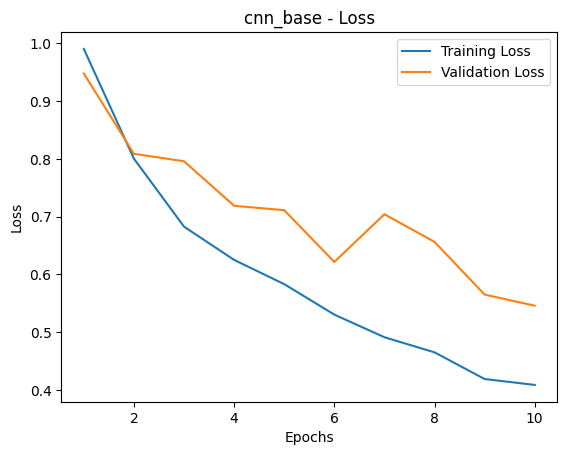

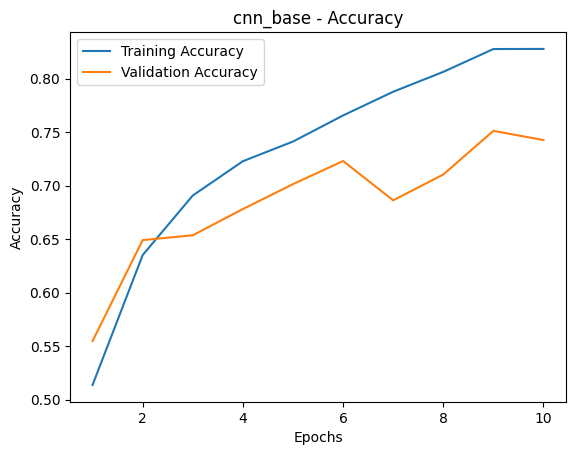

In [27]:
plot_kfold(base_histories, title_prefix=cfg_base["experiment_name"])

In [28]:
save_paths = get_save_paths(cfg_base["experiment_name"])

with open(save_paths["kfold_metrics"], "w") as f:
    for row in base_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(base_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(base_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(base_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(base_losses):.4f}\n")

In [29]:
del base_metrics
del base_histories
gc.collect()

base_metrics = None
base_histories = None

## Training + Evaluation

Using preprocessing: baseline
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.5510 - loss: 0.9365 - val_accuracy: 0.6904 - val_loss: 0.8606
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6755 - loss: 0.7330 - val_accuracy: 0.6864 - val_loss: 0.7516
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6964 - loss: 0.6709 - val_accuracy: 0.7088 - val_loss: 0.6742
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7347 - loss: 0.5755 - val_accuracy: 0.7454 - val_loss: 0.6128
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7418 - loss: 0.5766 - val_accuracy: 0.7413 - val_loss: 0.5760
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7735 - loss: 0.5078 - val_accuracy: 0.8045 - val_loss: 0.4865
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7607 - loss: 0.5390 - val_accuracy: 0.7576 - val_loss: 0.5747
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/ste

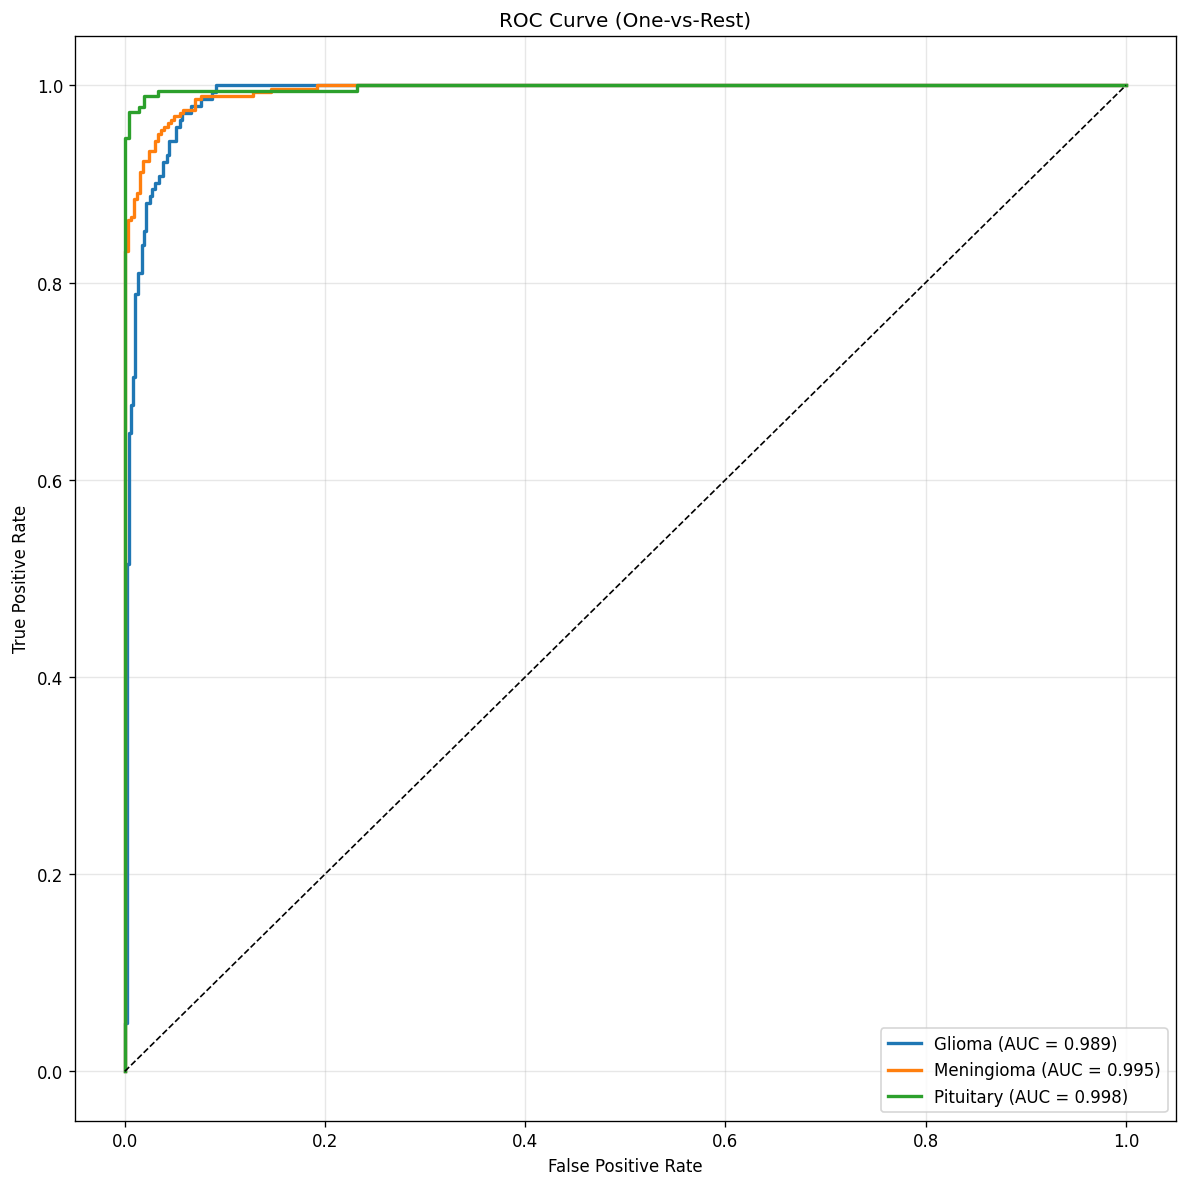


AUC per Class: 
Glioma: 0.9895
Meningioma: 0.9945
Pituitary: 0.9982
Macro AUC: 0.9941


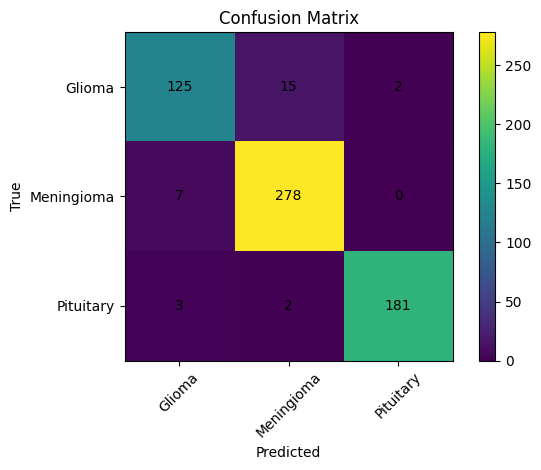

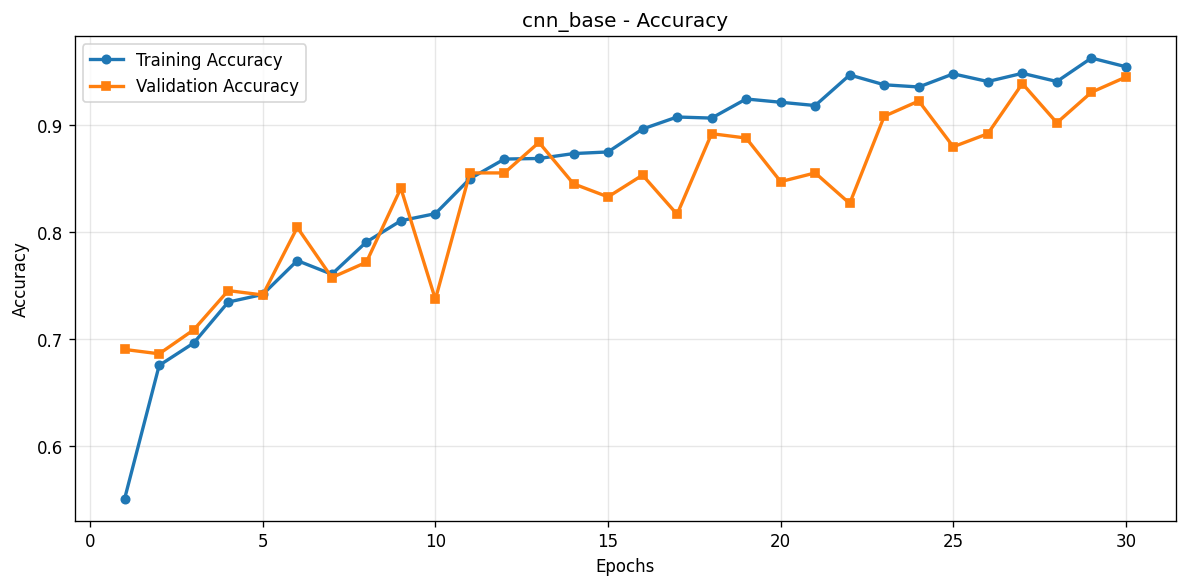

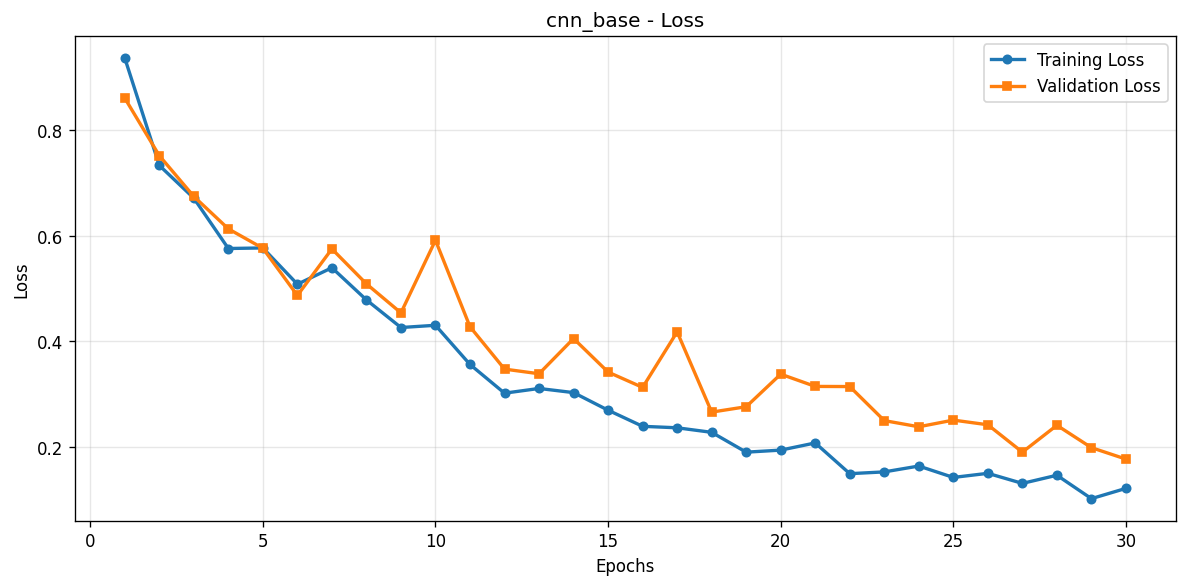

Loss:
  - loss [training dataset]: 0.121
  - loss [validation dataset]: 0.176

Accuracy:
  - accuracy [training dataset]: 95.46%
  - accuracy [validation dataset]: 94.50%


In [30]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc = train_test(
    cfg = cfg_base,
    save_model = True
)

In [31]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_base
gc.collect()

10016

In [32]:
tf.keras.backend.clear_session()

# Base CNN with Augmentation

In [45]:
cfg_aug = EXPERIMENTS["cnn_aug"]

## K-Fold(K=5)

In [46]:
aug_metrics, aug_histories = kfold(x_raw=x_train_val_raw,
                                     y=y_train_val_int,
                                     cfg = cfg_aug,
                                     K=K,
                                     BATCH_SIZE = BATCH_SIZE,
                                     LR = LR,
                                     EPOCHS = EPOCHS)


=== cnn_aug / Fold 1/5 ===
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - accuracy: 0.4827 - loss: 1.0668 - val_accuracy: 0.5214 - val_loss: 0.9254
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6398 - loss: 0.8148 - val_accuracy: 0.6701 - val_loss: 0.7444
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6617 - loss: 0.7645 - val_accuracy: 0.6538 - val_loss: 0.7825
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.6959 - loss: 0.6916 - val_accuracy: 0.6762 - val_loss: 0.7309
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.7061 - loss: 0.6393 - val_accuracy: 0.7088 - val_loss: 0.6432
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7383 - loss: 0.5853 - val_accuracy: 0.7210 - val_loss: 0.6110
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7857 - loss: 0.5112 - val_accuracy: 0.7271 - val_loss: 0.6929
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step 

In [47]:
aug_accuracy = [m["val_acc"] for m in aug_metrics]
aug_losses = [m["val_loss"] for m in aug_metrics]

print("Fold Accuracies:", aug_accuracy)
print("Mean Accuracy :", np.mean(aug_accuracy))
print("Std Accuracy  :", np.std(aug_accuracy))
print("Mean Loss     :", np.mean(aug_losses))
print("Std Loss      :", np.std(aug_losses))

Fold Accuracies: [0.8961303234100342, 0.7877551317214966, 0.8530611991882324, 0.918367326259613, 0.8530611991882324]
Mean Accuracy : 0.8616750359535217
Std Accuracy  : 0.04475205296558116
Mean Loss     : 0.3482422441244125
Std Loss      : 0.08862196607653804


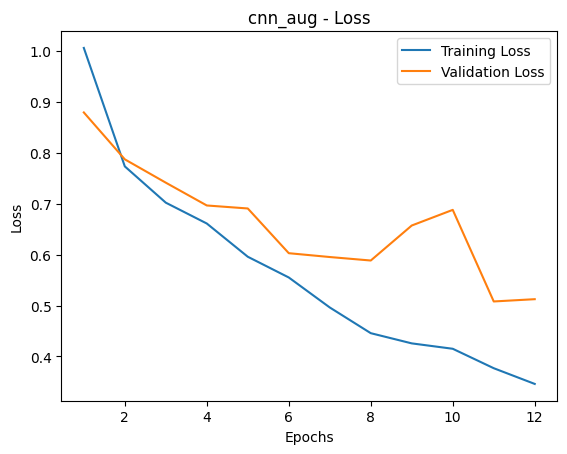

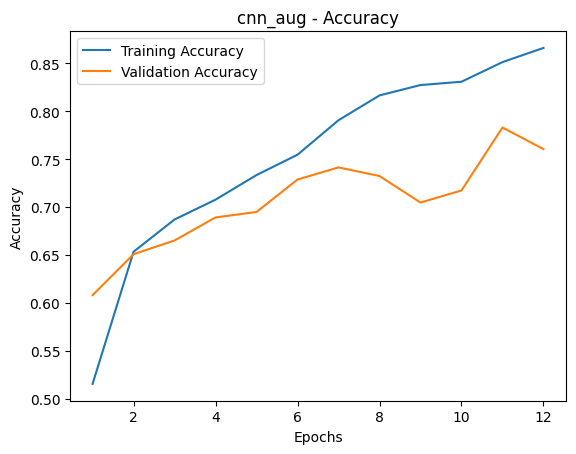

In [48]:
plot_kfold(aug_histories, title_prefix=cfg_aug["experiment_name"])

In [49]:
save_paths = get_save_paths(cfg_aug["experiment_name"])

with open(save_paths["kfold_metrics"], "w") as f:
    for row in aug_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(aug_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(aug_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(aug_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(aug_losses):.4f}\n")

In [50]:
del aug_metrics
del aug_histories
gc.collect()

aug_metrics = None
aug_histories = None

## Training + Evaluation

Using preprocessing: baseline
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.5173 - loss: 0.9827 - val_accuracy: 0.6843 - val_loss: 0.8976
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6668 - loss: 0.7526 - val_accuracy: 0.6965 - val_loss: 0.6912
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7015 - loss: 0.6493 - val_accuracy: 0.7210 - val_loss: 0.6811
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.7224 - loss: 0.6612 - val_accuracy: 0.7251 - val_loss: 0.6650
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7719 - loss: 0.5423 - val_accuracy: 0.7026 - val_loss: 0.6573
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7582 - loss: 0.5798 - val_accuracy: 0.7128 - val_loss: 0.6239
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7898 - loss: 0.4908 - val_accuracy: 0.7169 - val_loss: 0.6107
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/ste

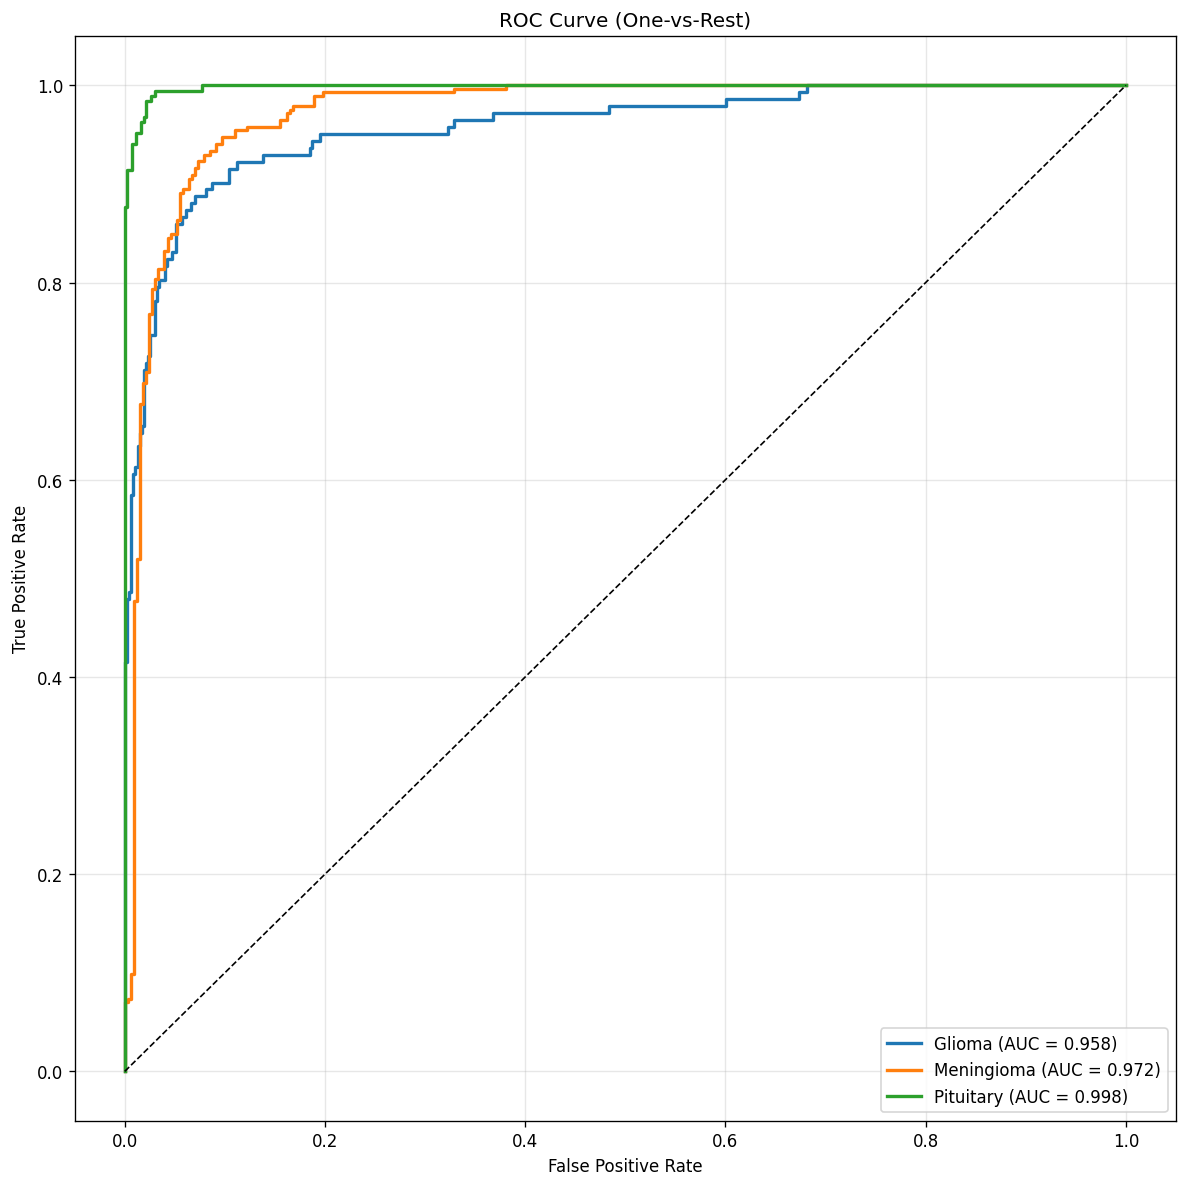


AUC per Class: 
Glioma: 0.9575
Meningioma: 0.9723
Pituitary: 0.9983
Macro AUC: 0.9760


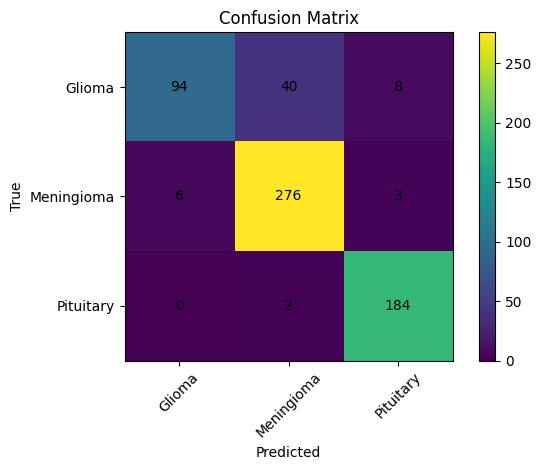

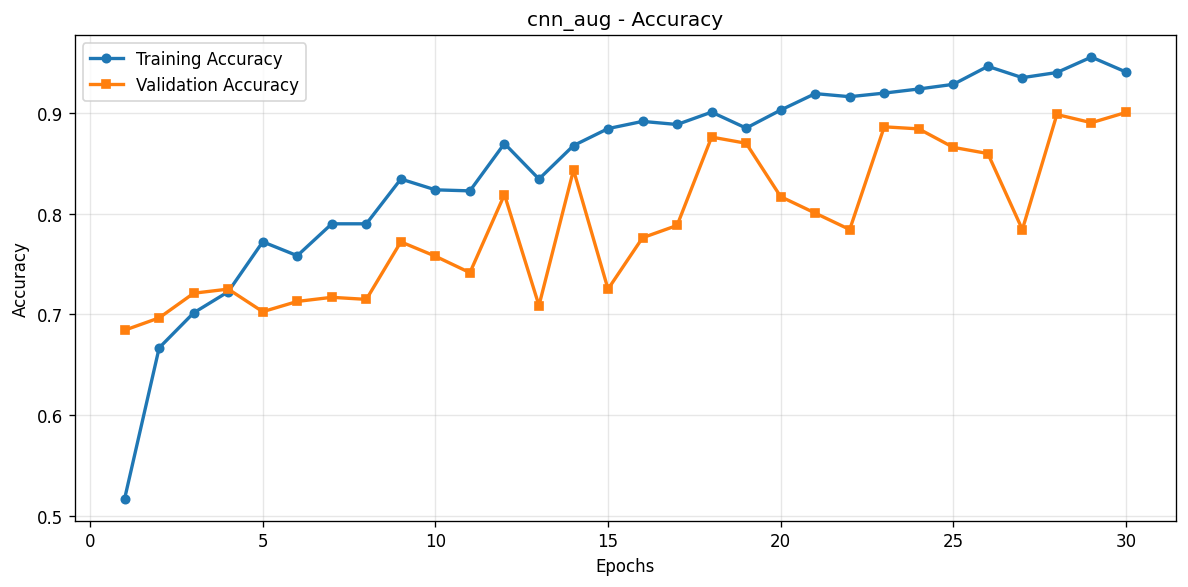

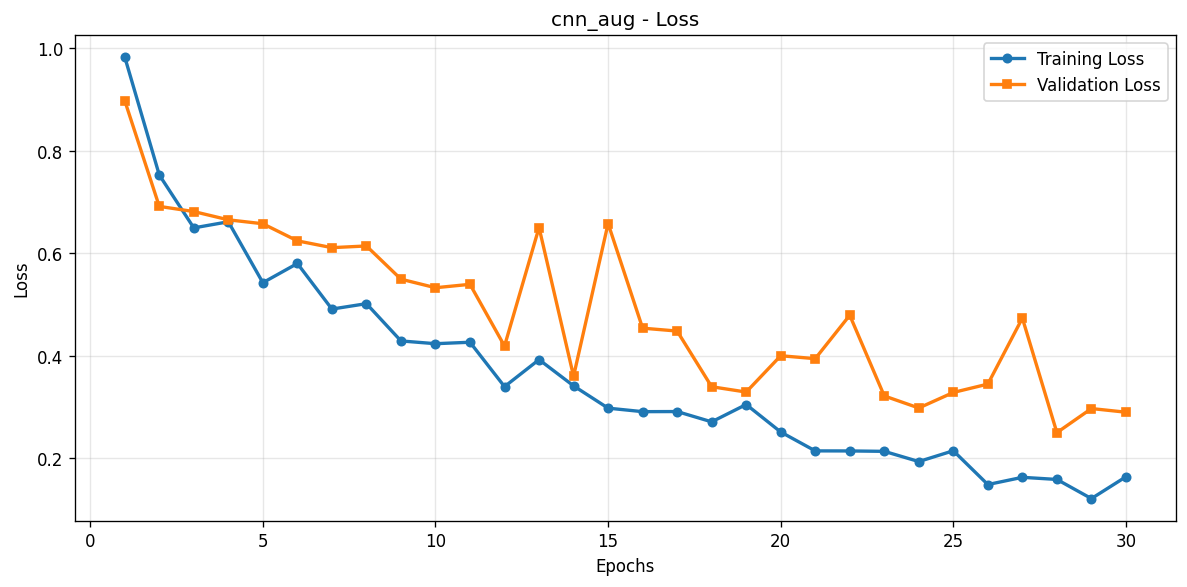

Loss:
  - loss [training dataset]: 0.163
  - loss [validation dataset]: 0.289

Accuracy:
  - accuracy [training dataset]: 94.03%
  - accuracy [validation dataset]: 90.02%


In [51]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc = train_test(
    cfg = cfg_aug,
    save_model = True
)

In [52]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_aug
gc.collect()

10011

In [53]:
tf.keras.backend.clear_session()